# Data Import


In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
df = pd.read_csv('test_sample.csv', sep=',', lineterminator='\n')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   platform         10000 non-null  object 
 1   account_id       10000 non-null  object 
 2   id               10000 non-null  object 
 3   created_time     10000 non-null  object 
 4   text_original    7613 non-null   object 
 5   text_additional  3 non-null      object 
 6   likes_count      9998 non-null   float64
 7   shares_count     5000 non-null   float64
 8   comments_count   9955 non-null   float64
 9   views_count      5621 non-null   float64
dtypes: float64(4), object(6)
memory usage: 781.4+ KB


,platform,account_id,id,created_time,text_original,text_additional,likes_count,shares_count,comments_count,views_count
0,Instagram,59141296785,C_00PPctR-o,2024-09-12 17:20:36.000000 +00:00,NaN,NaN,222.0,NaN,34.0,NaN
1,Instagram,60554087008,C_00W8KttVv,2024-09-12 17:21:27.000000 +00:00,C’è un gruppo sulla parola di Dio sulla mia ho...,NaN,391.0,NaN,37.0,NaN
2,Instagram,62605500679,C_026U_t3We,2024-09-12 17:43:38.000000 +00:00,𝐒𝐮𝐥 𝐦𝐢𝐨 𝐩𝐫𝐨𝐟𝐢𝐥𝐨 𝐜‘𝐞̀ 𝐮𝐧 𝐠𝐫𝐮𝐩𝐩𝐨 𝐝𝐢 𝐬𝐭𝐮𝐝𝐢𝐨 𝐬𝐮𝐥𝐥𝐚...,NaN,9.0,NaN,3.0,NaN
3,Instagram,58741537308,C_05B3hCYQn,2024-09-12 18:02:08.000000 +00:00,#Monza\n#Padova\n#Lecce\n#Latina\n#paroladelsi...,NaN,78.0,NaN,15.0,NaN
4,Instagram,58741537308,C_0BfOLiqRS,2024-09-12 09:57:22.000000 +00:00,#Monza\n#Padova\n#Lecce\n#Latina\n#paroladelsi...,NaN,129.0,NaN,16.0,NaN


In [3]:
df['platform'].value_counts()

platform
Instagram    2500
TikTok       2500
Facebook     2500
YouTube      2500
Name: count, dtype: int64

# Data Cleaning


In [4]:
#check missing values
df.isnull().sum()

platform              0
account_id            0
id                    0
created_time          0
text_original      2387
text_additional    9997
likes_count           2
shares_count       5000
comments_count       45
views_count        4379
dtype: int64

In [5]:
df['text_original'] = df['text_original'].fillna("No text")
df = df.drop('text_additional', axis=1)

In [6]:
df['created_time'] = pd.to_datetime(df['created_time'], errors='coerce')

df['date'] = df['created_time'].dt.date
df['hour'] = df['created_time'].dt.hour
df['weekday'] = df['created_time'].dt.day_name()

In [7]:
# missing data calculation in percents
def missing_percent(series):
    return series.isnull().mean() * 100

missing_percent_metrics = pd.DataFrame({
    'missing_views': df.groupby('platform')['views_count'].apply(missing_percent),
    'missing_shares': df.groupby('platform')['shares_count'].apply(missing_percent),
    'missing_likes': df.groupby('platform')['likes_count'].apply(missing_percent),
    'missing_comments': df.groupby('platform')['comments_count'].apply(missing_percent),
})

missing_percent_metrics

,missing_views,missing_shares,missing_likes,missing_comments
platform,,,,
Facebook,75.16,0.0,0.00,0.00
Instagram,100.00,100.0,0.08,1.08
TikTok,0.00,0.0,0.00,0.00
YouTube,0.00,100.0,0.00,0.72


In [8]:
df['likes_count'] = df['likes_count'].fillna(0)
df['comments_count'] = df['comments_count'].fillna(0)

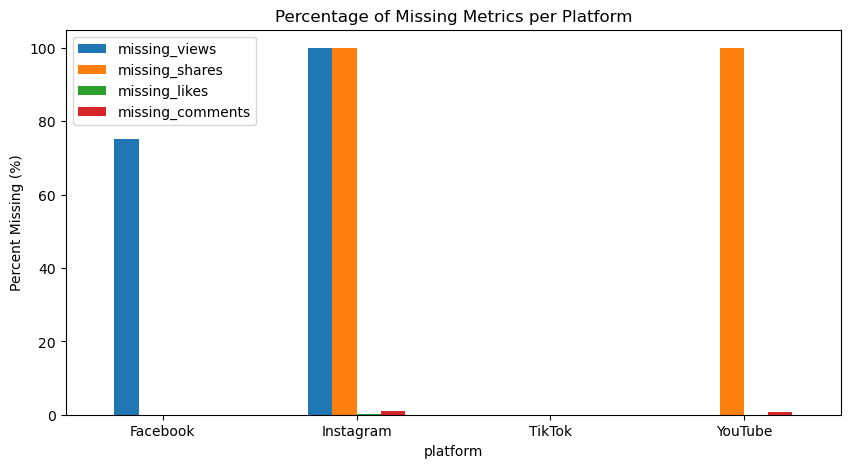

In [9]:
missing_percent_metrics.plot(kind='bar', figsize=(10,5))
plt.title("Percentage of Missing Metrics per Platform")
plt.ylabel("Percent Missing (%)")
plt.xticks(rotation=0)
plt.show()

Instagram is missing nearly all views count, shares count. Facebook has 75% missing views. YouTube is missing all shares.
TikTok has almost no missing metrics, making it the only platform where full engagement analysis is fully meaningful.

## Posting Activity Analysis

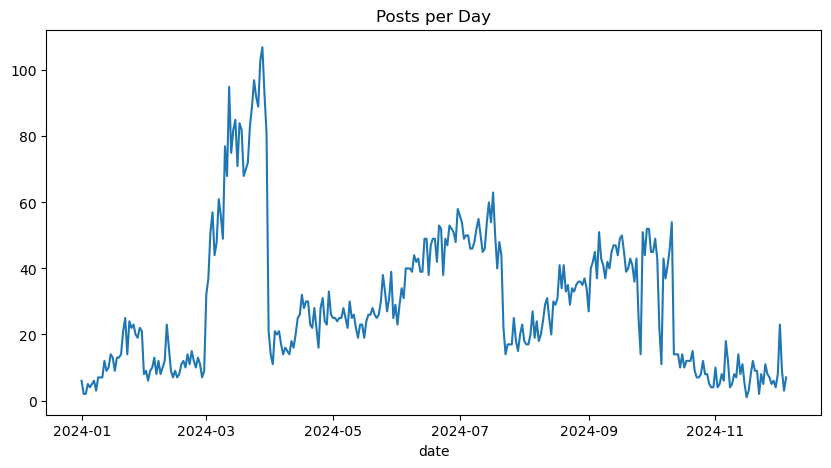

In [10]:
posts_per_day = df.groupby('date').size()
posts_per_day.plot(figsize=(10,5), title="Posts per Day")
plt.show()

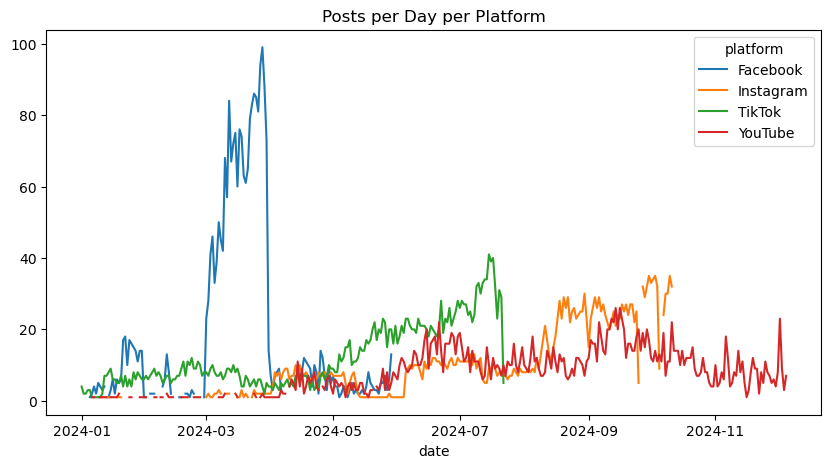

In [11]:
df.groupby(['platform','date']).size().unstack(0).plot(figsize=(10,5))
plt.title("Posts per Day per Platform")
plt.show()

The number of posts changes over time and differs between platforms. Facebook shows a brief spike in activity, while the other platforms have more gradual and variable trends. Overall, posting activity is not constant over time.

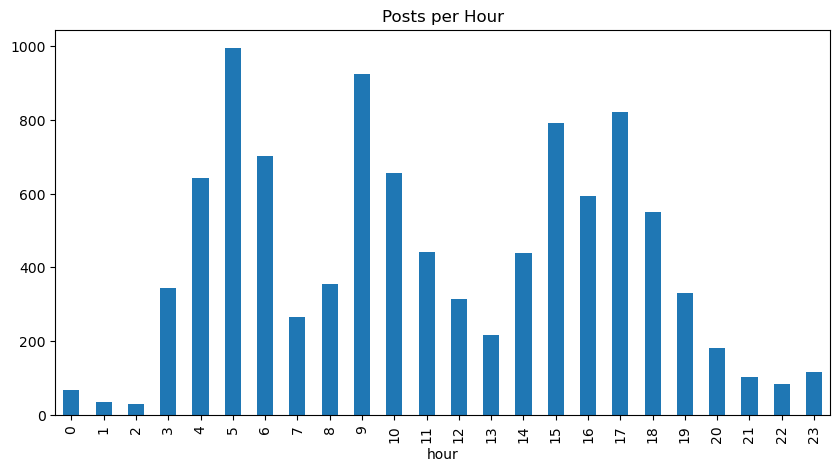

In [12]:
df.groupby('hour').size().plot(kind='bar', figsize=(10,5))
plt.title("Posts per Hour")
plt.show()

Posting activity varies strongly by hour, there is three clear visible picks on the plot, so it`s low activity during the night and clear peaks in the early morning (around 5 am), mid-morning (around 9-10 am), and afternoon (3-6 pm). So we could assume that users are most active during typical daytime hours rather than evenly throughout the day.

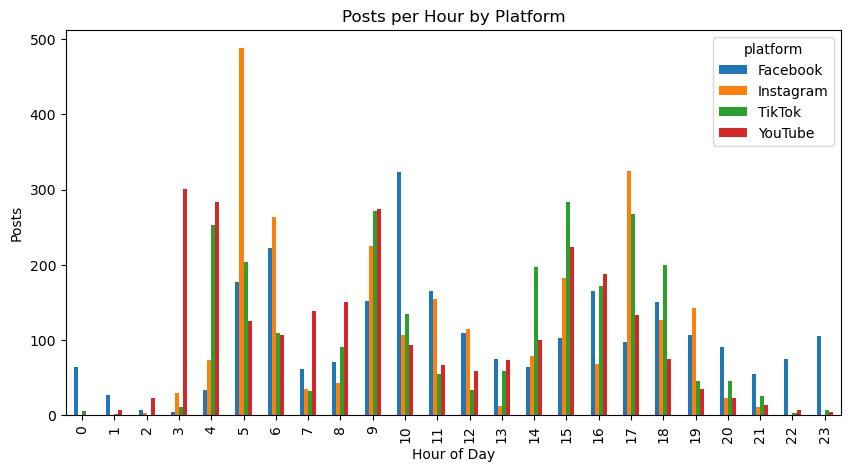

In [13]:
posts_per_hour_platform = df.groupby(['platform','hour']).size().unstack(0)
posts_per_hour_platform.plot(kind='bar', figsize=(10,5))
plt.title("Posts per Hour by Platform")
plt.ylabel("Posts")
plt.xlabel("Hour of Day")
plt.show()

Pretty the same for all of the given platforms. Posting activity changes by hour, with very low activity at night and higher activity during the day. Instagram and TikTok show sharper peaks at certain hours, while Facebook activity is more evenly distributed.

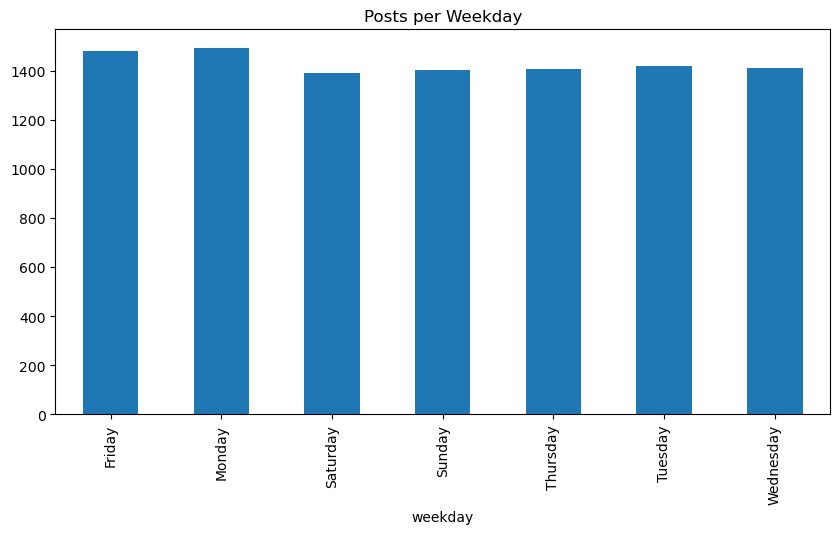

In [14]:
df.groupby('weekday').size().plot(kind='bar', figsize=(10,5))
plt.title("Posts per Weekday")
plt.show()

There is no correlation between day of the week and posts frequence.

## Text & Hashtag Analysis

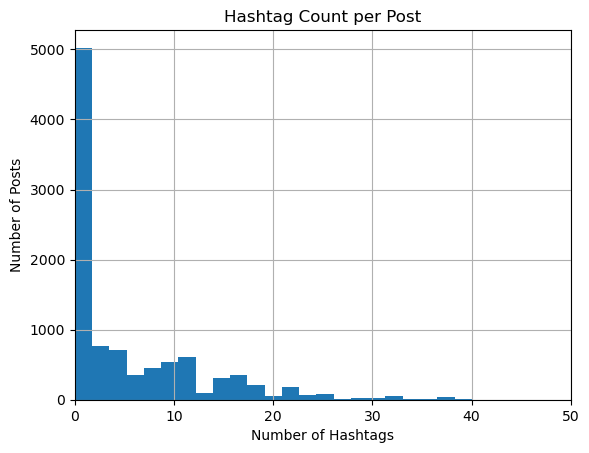

In [15]:
# hashtags count calculation
def count_hashtags(text):
    if isinstance(text, str):
        return text.count('#')
    return 0

df['hashtag_count'] = df['text_original'].apply(count_hashtags)

plt.figure()
df['hashtag_count'].hist(bins=50)
plt.xlim(0, 50)
plt.title('Hashtag Count per Post')
plt.xlabel('Number of Hashtags')
plt.ylabel('Number of Posts')
plt.show()

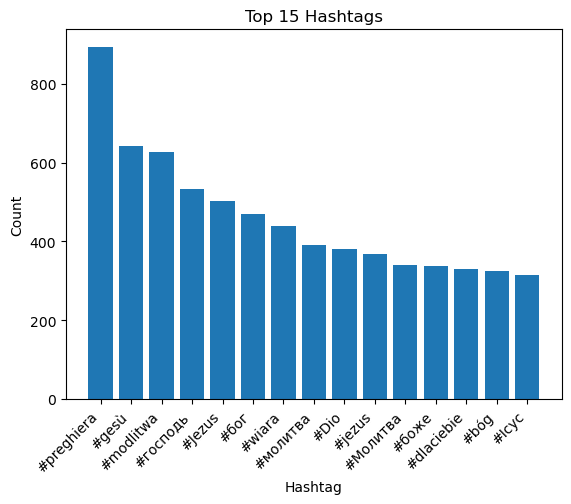

In [16]:
#top hashtags
hashtags = df['text_original'].fillna("").str.findall(r"#\w+").explode() 
top_hashtags = Counter(hashtags).most_common(15)

top_df = pd.DataFrame(top_hashtags, columns=['hashtag', 'count'])

plt.figure()
plt.bar(top_df['hashtag'], top_df['count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Hashtag')
plt.ylabel('Count')
plt.title('Top 15 Hashtags')
plt.show()

Analysing this data we could see the most popular discussed topics as God, Jesus, pray, appearing in multiple languages, which suggests that the dataset is strongly centered around religious topics.

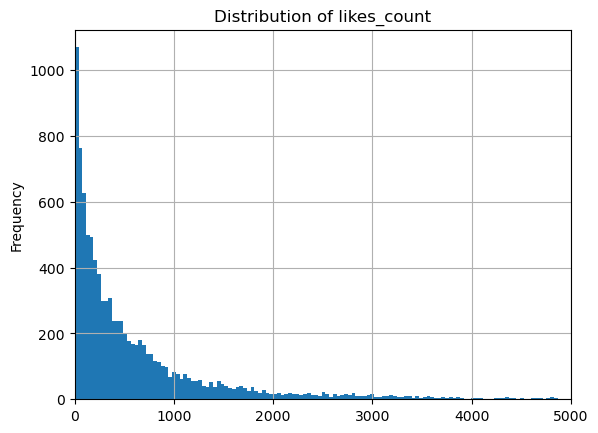

In [17]:
plt.figure()
plt.xlim(0, 5000)

df['likes_count'].dropna().hist(bins=5000)
plt.title('Distribution of likes_count')
plt.ylabel('Frequency')
plt.show()

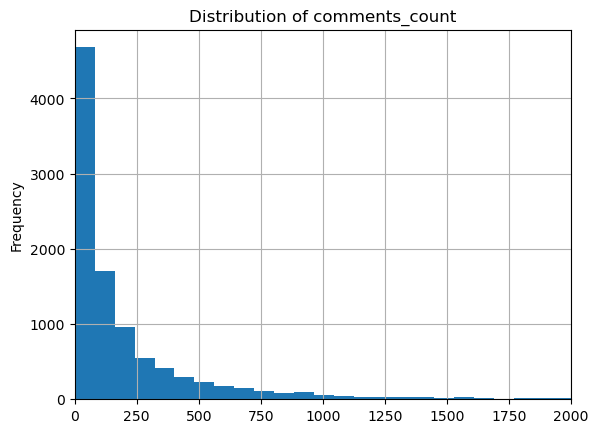

In [18]:
plt.figure()
plt.xlim(0, 2000)

df['comments_count'].dropna().hist(bins=1000)
plt.title('Distribution of comments_count')
plt.ylabel('Frequency')
plt.show()

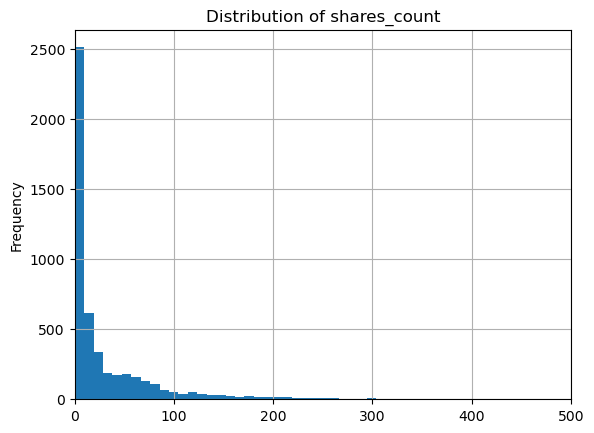

In [19]:
plt.figure()
plt.xlim(0, 500)

df['shares_count'].dropna().hist(bins=5000)
plt.title('Distribution of shares_count')
plt.ylabel('Frequency')
plt.show()

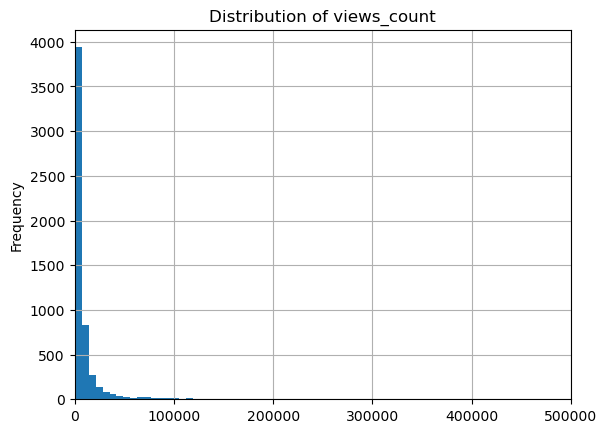

In [20]:
plt.figure()
plt.xlim(0, 500000)

df['views_count'].dropna().hist(bins=500)
plt.title('Distribution of views_count')
plt.ylabel('Frequency')
plt.show()

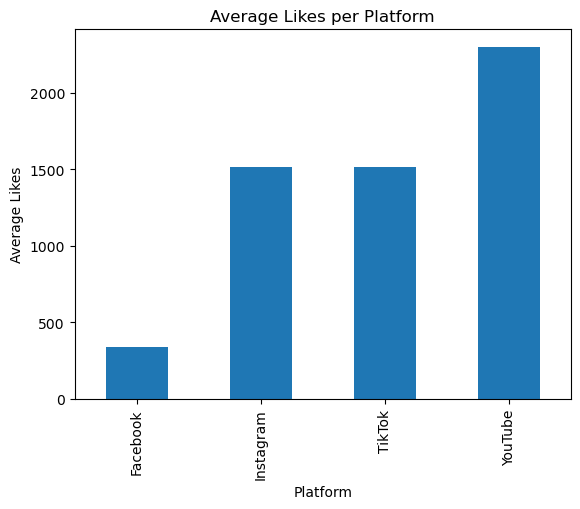

In [21]:
plt.figure()
df.groupby('platform')['likes_count'].mean().plot(kind='bar')
plt.title('Average Likes per Platform')
plt.xlabel('Platform')
plt.ylabel('Average Likes')
plt.show()

So users more likely likes posts in YouTube, TikTok and Instagram, while engagement on Facebook is more than five times lower compared to these platforms.

# Conclusions

This exploratory data analysis highlights clear patterns in posting behavior across time, platforms, and content. Activity levels vary by hour and day, differ between platforms, and are influenced by recurring topics and hashtags. Overall, the data shows enough structure and variability to justify further, more focused analysis if required.